# Plot R ggtree circular phylogenetic trees 

- This notebook generates circular phylogenetic trees with R ggtree (aesthetically look better than the python ete3 default plot)
- Reproduce the HCT116 homopolymer vs di- to hexanucleotide circular phylogenetic trees from the paper

## Requirements:
- Newick tree file
- CSV samplesheet with columns: sample_id, color, group


## 1. Setup and Package Installation


In [ ]:
# Install required packages if not already installed
# Uncomment the lines below if you need to install packages

# if (!requireNamespace("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# install.packages(c("ape", "dplyr", "ggplot2"))
#BiocManager::install(c("ggtree", "ggtreeExtra"))


In [ ]:
# Load required libraries
suppressPackageStartupMessages({
  library(ggtree)
  library(ggtreeExtra)
  library(ape)
  library(dplyr)
  library(ggplot2)
})


## 2. Configuration Parameters

Adjust these parameters to customize your visualization:


## TW1nt12k Dataset Visualization

In [ ]:
# Configuration parameters - MODIFY THESE AS NEEDED

# All inputs/outputs are under DATA_DIR so this notebook can be copied to
# software/RETrace2/notebooks/ and run without changing the working directory.
DATA_DIR <- "/home/tony/Scratch/RETrace2/20210920_NovaSeq_HCT116_1nt12k_2nt24k"
if (!dir.exists(DATA_DIR)) {
  stop("DATA_DIR not found: ", DATA_DIR)
}

# File paths
SAMPLESHEET_FILE <- file.path(DATA_DIR, "20210920_HCT116_1nt12k_samplesheet.csv")
# Use the bootstrap newick to print integer support values at internal nodes (SHOW_BOOTSTRAP must be TRUE)
# Switch back to newick-original.txt and set SHOW_BOOTSTRAP <- FALSE if you don't want bootstrap
TREE_FILE <- file.path(
  DATA_DIR,
  "results_TW1nt12k_500targets_minqual0_minreads10/phylo/20210920_HCT116_TW1nt12k_rerun.buildPhylo.newick-bootstrap.txt"
)
OUTPUT_PREFIX <- file.path(DATA_DIR, "20210920_HCT116_TW1nt12k_circular_ggtree_bootstrap")

# Visual parameters
COLOR_BACKGROUND <- FALSE  # Set to TRUE to apply colors to text background instead of node circles
PLOT_WIDTH <- 16
PLOT_HEIGHT <- 12
DPI <- 500
TIP_LABEL_SIZE <- 3.7
NODE_SIZE <- 3
LEGEND_TEXT_SIZE <- 22
LEGEND_TITLE_SIZE <- 24

# Ring parameters
INNER_RING_OFFSET <- 1.6
RING_WIDTH <- 4

# Bootstrap parameters
# SHOW_BOOTSTRAP: small white-backed integer percentages on internal nodes (low-key; no on-plot bootstrap legend)
# Requires a bootstrap newick (node labels are 0-1 fractions); set to FALSE for original newicks
SHOW_BOOTSTRAP <- TRUE
BOOTSTRAP_LABEL_SIZE <- 2.5  # small so bootstrap is readable but not the visual focus
BOOTSTRAP_COLOR <- "grey30"
BOOTSTRAP_NUDGE <- 0.32       # sit on the parent branch, slightly off the node fork

cat("Configuration set:\n")
cat("DATA_DIR:", DATA_DIR, "\n")
cat("Samplesheet:", SAMPLESHEET_FILE, "\n")
cat("Tree file:", TREE_FILE, "\n")
cat("Output prefix:", OUTPUT_PREFIX, "\n")
cat("Color background:", COLOR_BACKGROUND, "\n")


Configuration set:
Samplesheet: /home/tony/Scratch/RETrace2/20210920_NovaSeq_HCT116_1nt12k_2nt24k/20210920_HCT116_1nt12k_samplesheet.csv 
Tree file: results_TW1nt12k_500targets_minqual0_minreads10/phylo/20210920_HCT116_TW1nt12k_rerun.buildPhylo.newick-bootstrap.txt 
Output prefix: 20210920_HCT116_TW1nt12k_circular_ggtree_bootstrap 
Color background: FALSE 


## 3. Data Loading and Preprocessing


In [ ]:
# Load tree
tree <- read.tree(TREE_FILE)

cat("Tree loaded successfully!\n")
cat("Number of tips:", length(tree$tip.label), "\n")
cat("Tree type:", class(tree), "\n")

# Display first few tip labels
cat("\nFirst 10 tip labels:\n")
print(head(tree$tip.label, 10))


Tree loaded successfully!
Number of tips: 34 
Tree type: phylo 

First 10 tip labels:
 [1] "2-1-C4_3-7-G7_Plate1-1E" "2-1-C4_3-7-G7_Plate1-3C"
 [3] "2-1-C4_3-7-G7_Plate1-2B" "2-1-C4_3-7-G7_Plate1-2D"
 [5] "2-1-C4_3-7-G7_Plate1-2F" "2-1-C4_3-7-G7_Plate1-2C"
 [7] "2-1-C4_3-7-G7_Plate1-3G" "2-1-C4_3-7-G7_Plate1-2G"
 [9] "2-1-C4_3-7-G7_Plate1-3B" "2-1-F7_3-3-B9_Plate1-6G"


In [ ]:
# Load sample data
samples <- read.csv(SAMPLESHEET_FILE, stringsAsFactors = FALSE)

cat("Sample data loaded successfully!\n")
cat("Number of samples:", nrow(samples), "\n")
cat("Columns:", colnames(samples), "\n")

# Display first few rows
cat("\nFirst few rows of sample data:\n")
print(head(samples))

# Check for unique groups
cat("\nUnique groups:\n")
print(unique(samples$group))


Sample data loaded successfully!
Number of samples: 54 
Columns: sample_id ms_fastq_1 meth_fastq_1 group color 

First few rows of sample data:
                sample_id
1 2-1-C4_3-7-G7_Plate1-1B
2 2-1-C4_3-7-G7_Plate1-1C
3 2-1-C4_3-7-G7_Plate1-1D
4 2-1-C4_3-7-G7_Plate1-1E
5 2-1-C4_3-7-G7_Plate1-1F
6 2-1-C4_3-7-G7_Plate1-1G
                                                                                                                                                                        ms_fastq_1
1 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20210920_NovaSeq_HCT116_1nt12k_2nt24k/0_Raw_Data/Fastq/MS_TW1nt12k_HCT116_SC_2-1-C4_3-7-G7_20210907_Plate1-1B.fastq.gz
2 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20210920_NovaSeq_HCT116_1nt12k_2nt24k/0_Raw_Data/Fastq/MS_TW1nt12k_HCT116_SC_2-1-C4_3-7-G7_20210907_Plate1-1C.fastq.gz
3 /datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20210920_NovaSeq_HCT116_1nt12k_2nt24k/0_Raw_Data/Fastq/MS_TW1nt12k_HCT116_SC_

In [ ]:
# Handle missing values with defaults
if (!'color' %in% colnames(samples)) {
  samples$color <- 'grey'
  cat("Added default 'color' column\n")
} else {
  samples$color <- ifelse(is.na(samples$color) | samples$color == '', 'grey', samples$color)
  cat("Processed 'color' column\n")
}

# Display updated sample data
cat("\nSample data structure:\n")
print(str(samples))


Processed 'color' column

Sample data structure:
'data.frame':	54 obs. of  5 variables:
 $ sample_id   : chr  "2-1-C4_3-7-G7_Plate1-1B" "2-1-C4_3-7-G7_Plate1-1C" "2-1-C4_3-7-G7_Plate1-1D" "2-1-C4_3-7-G7_Plate1-1E" ...
 $ ms_fastq_1  : chr  "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20210920_NovaSeq_HCT116_1nt12k_2nt24k/0_Raw_Data/Fast"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20210920_NovaSeq_HCT116_1nt12k_2nt24k/0_Raw_Data/Fast"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20210920_NovaSeq_HCT116_1nt12k_2nt24k/0_Raw_Data/Fast"| __truncated__ "/datasets/s3/altos-lab-kzhang/tcheng/retrace2-data-seqraw/20210920_NovaSeq_HCT116_1nt12k_2nt24k/0_Raw_Data/Fast"| __truncated__ ...
 $ meth_fastq_1: logi  NA NA NA NA NA NA ...
 $ group       : chr  "2-1-C4_3-7-G7" "2-1-C4_3-7-G7" "2-1-C4_3-7-G7" "2-1-C4_3-7-G7" ...
 $ color       : chr  "#f4a6a6" "#f4a6a6" "#f4a6a6" "#f4a6a6" ...
NULL


## 4. Data Preparation for Visualization


In [ ]:
# Prepare data for tree - only color column for tip labels
tip_label_data <- samples %>% 
  select(sample_id, color) %>%
  rename(label = sample_id)
rownames(tip_label_data) <- tip_label_data$label

# Prepare data for inner ring with group names for legend
group_ring_data <- samples %>%
  select(sample_id, color, group) %>%
  rename(label = sample_id)

cat("Data preparation completed!\n")
cat("Tip label data rows:", nrow(tip_label_data), "\n")
cat("Group ring data rows:", nrow(group_ring_data), "\n")


Data preparation completed!
Tip label data rows: 54 
Group ring data rows: 54 


In [ ]:
# Custom rename dictionary for group names (customize as needed)
rename_dict <- list(
  'Brain_LeftAnteriorCortex' = 'Brain Left Anterior Cortex',
  'Brain_LeftPosteriorCortex' = 'Brain Left Posterior Cortex',
  'Kidney_Left-Cortex-1' = 'Kidney Left Cortex',
  'Kidney_Right-Cortex-1' = 'Kidney Right Cortex',
  'Liver_LeftLobe' = 'Liver Left Lobe',
  'Liver_MedianLobe' = 'Liver Median Lobe',
  'Liver_RightLobe' = 'Liver Right Lobe'
)

# Function to rename based on dictionary, leave unchanged if not in dict
rename_labels <- function(x, dict) {
  sapply(x, function(name) {
    if (name %in% names(dict)) {
      dict[[name]]
    } else {
      name
    }
  })
}

# Apply custom renaming to group names
group_names_clean <- rename_labels(unique(samples$group), rename_dict)
group_colors_map <- setNames(unique(samples$color), group_names_clean)

# Update the group_ring_data to use cleaned names
group_ring_data$group <- rename_labels(group_ring_data$group, rename_dict)

cat("Label cleaning completed!\n")
cat("Group colors map:\n")
print(group_colors_map)


Label cleaning completed!
Group colors map:
2-1-C4_3-7-G7 2-1-F7_3-3-B9 2-1-H9_3-4-D8 
    "#f4a6a6"     "#b8d4b8"     "#a8c8ec" 


## 5. Tree Visualization


In [ ]:
# Set plot size for notebook display
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 150)

# Basic tree plot - circular layout only
p <- ggtree(tree, layout = 'circular', branch.length = 'none', size = 1)

# Join ONLY color data to tree for tip labels
p <- p %<+% tip_label_data

cat("Basic tree structure created!\n")


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggtree package.
  Please report the issue at <https://github.com/YuLab-SMU/ggtree/issues>.”


Basic tree structure created!


In [ ]:
# Add tip labels with or without background color
if (COLOR_BACKGROUND) {
  # Text with colored background - smaller font to avoid overlap
  p <- p + geom_tiplab(aes(fill = color), 
                       size = TIP_LABEL_SIZE, color = 'black', 
                       geom = 'label', 
                       label.padding = unit(0.1, "lines")) +
    scale_fill_identity()
  cat("Added colored background tip labels\n")
} else {
  # Colored node circles with plain text - smaller font with offset
  p <- p + geom_tippoint(aes(color = color), size = NODE_SIZE) +
    geom_tiplab(size = TIP_LABEL_SIZE, offset = 0.6) +  # Small offset to push text away from nodes
    scale_color_identity()
  cat("Added colored node circles with plain text labels\n")
}


Added colored node circles with plain text labels


In [ ]:
# Bootstrap values as integer percentages at each internal node (replaces 0/25/50/75/100 circle bins).
# Added BEFORE geom_fruit so ggtreeExtra coordinate expansion does not shift node positions.
if (SHOW_BOOTSTRAP) {
  tree_node_labels <- tree$node.label
  n_nonempty <- sum(!is.na(tree_node_labels) & nzchar(tree_node_labels))
  cat(sprintf("Bootstrap check: %d internal nodes, %d with non-empty labels\n",
              length(tree_node_labels), n_nonempty))
  if (n_nonempty > 0) {
    n_tips         <- length(tree$tip.label)
    internal_nodes <- seq(n_tips + 1L, n_tips + tree$Nnode)
    boot_numeric   <- suppressWarnings(as.numeric(tree$node.label))
    # Convert 0-1 fractions to 0-100; leave values already on a percent scale as-is
    boot_pct       <- ifelse(!is.na(boot_numeric) & boot_numeric <= 1.5,
                             boot_numeric * 100, boot_numeric)
    bootstrap_lab  <- ifelse(is.na(boot_pct), NA_character_,
                             as.character(round(boot_pct)))
    bootstrap_df   <- data.frame(
      node          = internal_nodes,
      bootstrap     = boot_pct,
      bootstrap_lab = bootstrap_lab,
      stringsAsFactors = FALSE
    )

    # Join bootstrap values now; draw the numbers AFTER geom_fruit so they sit on top of branches
    p <- p %<+% bootstrap_df
    cat("Joined bootstrap values (labels drawn after the clone ring)\n")

    # --- Internal vs terminal-node support summary (for reviewer) ---
    clone_of <- setNames(as.character(samples$group), samples$sample_id)
    short_clone <- function(x) {
      # "2-1-C4_3-7-G7" -> "C4"
      ifelse(grepl("-C4_", x), "C4",
             ifelse(grepl("-F7_", x), "F7",
                    ifelse(grepl("-H9_", x), "H9", x)))
    }

    tips_under <- function(phy, node) {
      if (node <= length(phy$tip.label)) return(node)
      kids <- phy$edge[phy$edge[, 1] == node, 2]
      unlist(lapply(kids, function(k) tips_under(phy, k)))
    }

    node_info <- do.call(rbind, lapply(internal_nodes, function(nd) {
      kids    <- tree$edge[tree$edge[, 1] == nd, 2]
      tip_ids <- tips_under(tree, nd)
      clones  <- unique(short_clone(clone_of[tree$tip.label[tip_ids]]))
      clones  <- clones[!is.na(clones)]
      n_tip_children <- sum(kids <= n_tips)
      data.frame(
        node            = nd,
        n_tips          = length(tip_ids),
        n_clones        = length(clones),
        clones          = paste(sort(clones), collapse = ","),
        n_tip_children  = n_tip_children,
        is_terminal     = n_tip_children >= 1L,
        stringsAsFactors = FALSE
      )
    }))
    node_info$bootstrap <- boot_pct

    summarize_boot <- function(x) {
      x <- x[!is.na(x)]
      if (length(x) == 0) return("n=0")
      sprintf("n=%d  median=%.0f%%  mean=%.0f%%  >=70%%: %d/%d  >=90%%: %d/%d",
              length(x), median(x), mean(x),
              sum(x >= 70), length(x), sum(x >= 90), length(x))
    }

    cat("\nBootstrap support: terminal vs internal nodes\n")
    cat("  Terminal splits (node has ≥1 tip child):  ",
        summarize_boot(node_info$bootstrap[node_info$is_terminal]), "\n")
    cat("  Internal splits (both children internal): ",
        summarize_boot(node_info$bootstrap[!node_info$is_terminal]), "\n")
    cat("  Within-clone nodes (all descendants one clone): ",
        summarize_boot(node_info$bootstrap[node_info$n_clones == 1]), "\n")
    cat("  Between-clone nodes (descendants mix clones):   ",
        summarize_boot(node_info$bootstrap[node_info$n_clones > 1]), "\n")

    cat("\nClone-defining nodes (largest monophyletic clade per clone):\n")
    for (cl in sort(unique(short_clone(clone_of[tree$tip.label])))) {
      sub <- node_info[node_info$n_clones == 1 & node_info$clones == cl, ]
      if (nrow(sub) == 0) {
        cat(sprintf("  %s: not recovered as a monophyletic clade\n", cl))
      } else {
        def <- sub[which.max(sub$n_tips), ]
        cat(sprintf("  %s: bootstrap=%s%%  (%d / %d cells)\n",
                    cl, ifelse(is.na(def$bootstrap), "NA",
                               as.character(round(def$bootstrap))),
                    def$n_tips, sum(short_clone(clone_of[tree$tip.label]) == cl)))
      }
    }

    out_tsv <- paste0(OUTPUT_PREFIX, ".node_bootstrap.tsv")
    write.table(node_info, out_tsv, sep = "\t", row.names = FALSE, quote = FALSE)
    cat("Wrote", out_tsv, "\n")
  } else {
    warning(
      "No non-empty internal node labels found. ",
      "Pass a bootstrap newick (e.g. *.buildPhylo.newick-bootstrap.txt) or set SHOW_BOOTSTRAP <- FALSE."
    )
  }
} else {
  cat("Bootstrap display disabled (SHOW_BOOTSTRAP = FALSE)\n")
}

Bootstrap check: 33 internal nodes, 32 with non-empty labels
Joined bootstrap values (labels drawn after the clone ring)

Bootstrap support: terminal vs internal nodes
  Terminal splits (node has ≥1 tip child):   n=21  median=46%  mean=53%  >=70%: 6/21  >=90%: 1/21 
  Internal splits (both children internal):  n=11  median=33%  mean=39%  >=70%: 2/11  >=90%: 1/11 
  Within-clone nodes (all descendants one clone):  n=31  median=39%  mean=47%  >=70%: 7/31  >=90%: 2/31 
  Between-clone nodes (descendants mix clones):    n=1  median=75%  mean=75%  >=70%: 1/1  >=90%: 0/1 

Clone-defining nodes (largest monophyletic clade per clone):
  C4: bootstrap=96%  (9 / 9 cells)
  F7: bootstrap=35%  (14 / 14 cells)
  H9: bootstrap=41%  (11 / 11 cells)
Wrote 20210920_HCT116_TW1nt12k_circular_ggtree_bootstrap.node_bootstrap.tsv 


In [ ]:
# Add inner continuous ring for group color (no clone legend on TW1nt; CA plot carries the shared legend)
p <- p + geom_fruit(
    data = group_ring_data,
    geom = geom_tile,
    mapping = aes(y = label, x = 2, fill = group),
    pwidth = 0.1,
    width = RING_WIDTH,
    offset = INNER_RING_OFFSET
  ) + 
  scale_fill_manual(
    values = group_colors_map,
    name = "HCT116 Clone",
    guide = "none"
  )

cat("Added inner ring for group colors\n")


! The following column names/name: color are/is the same to tree data, the tree data column names are : label, y, angle, color, bootstrap, bootstrap_lab.



Added inner ring for group colors


Warning message in geom_label2(aes(subset = !isTip & !is.na(bootstrap_lab), label = bootstrap_lab, :
“Ignoring unknown parameters: `label.size`”


Added bootstrap support values at internal nodes
Applied final theming


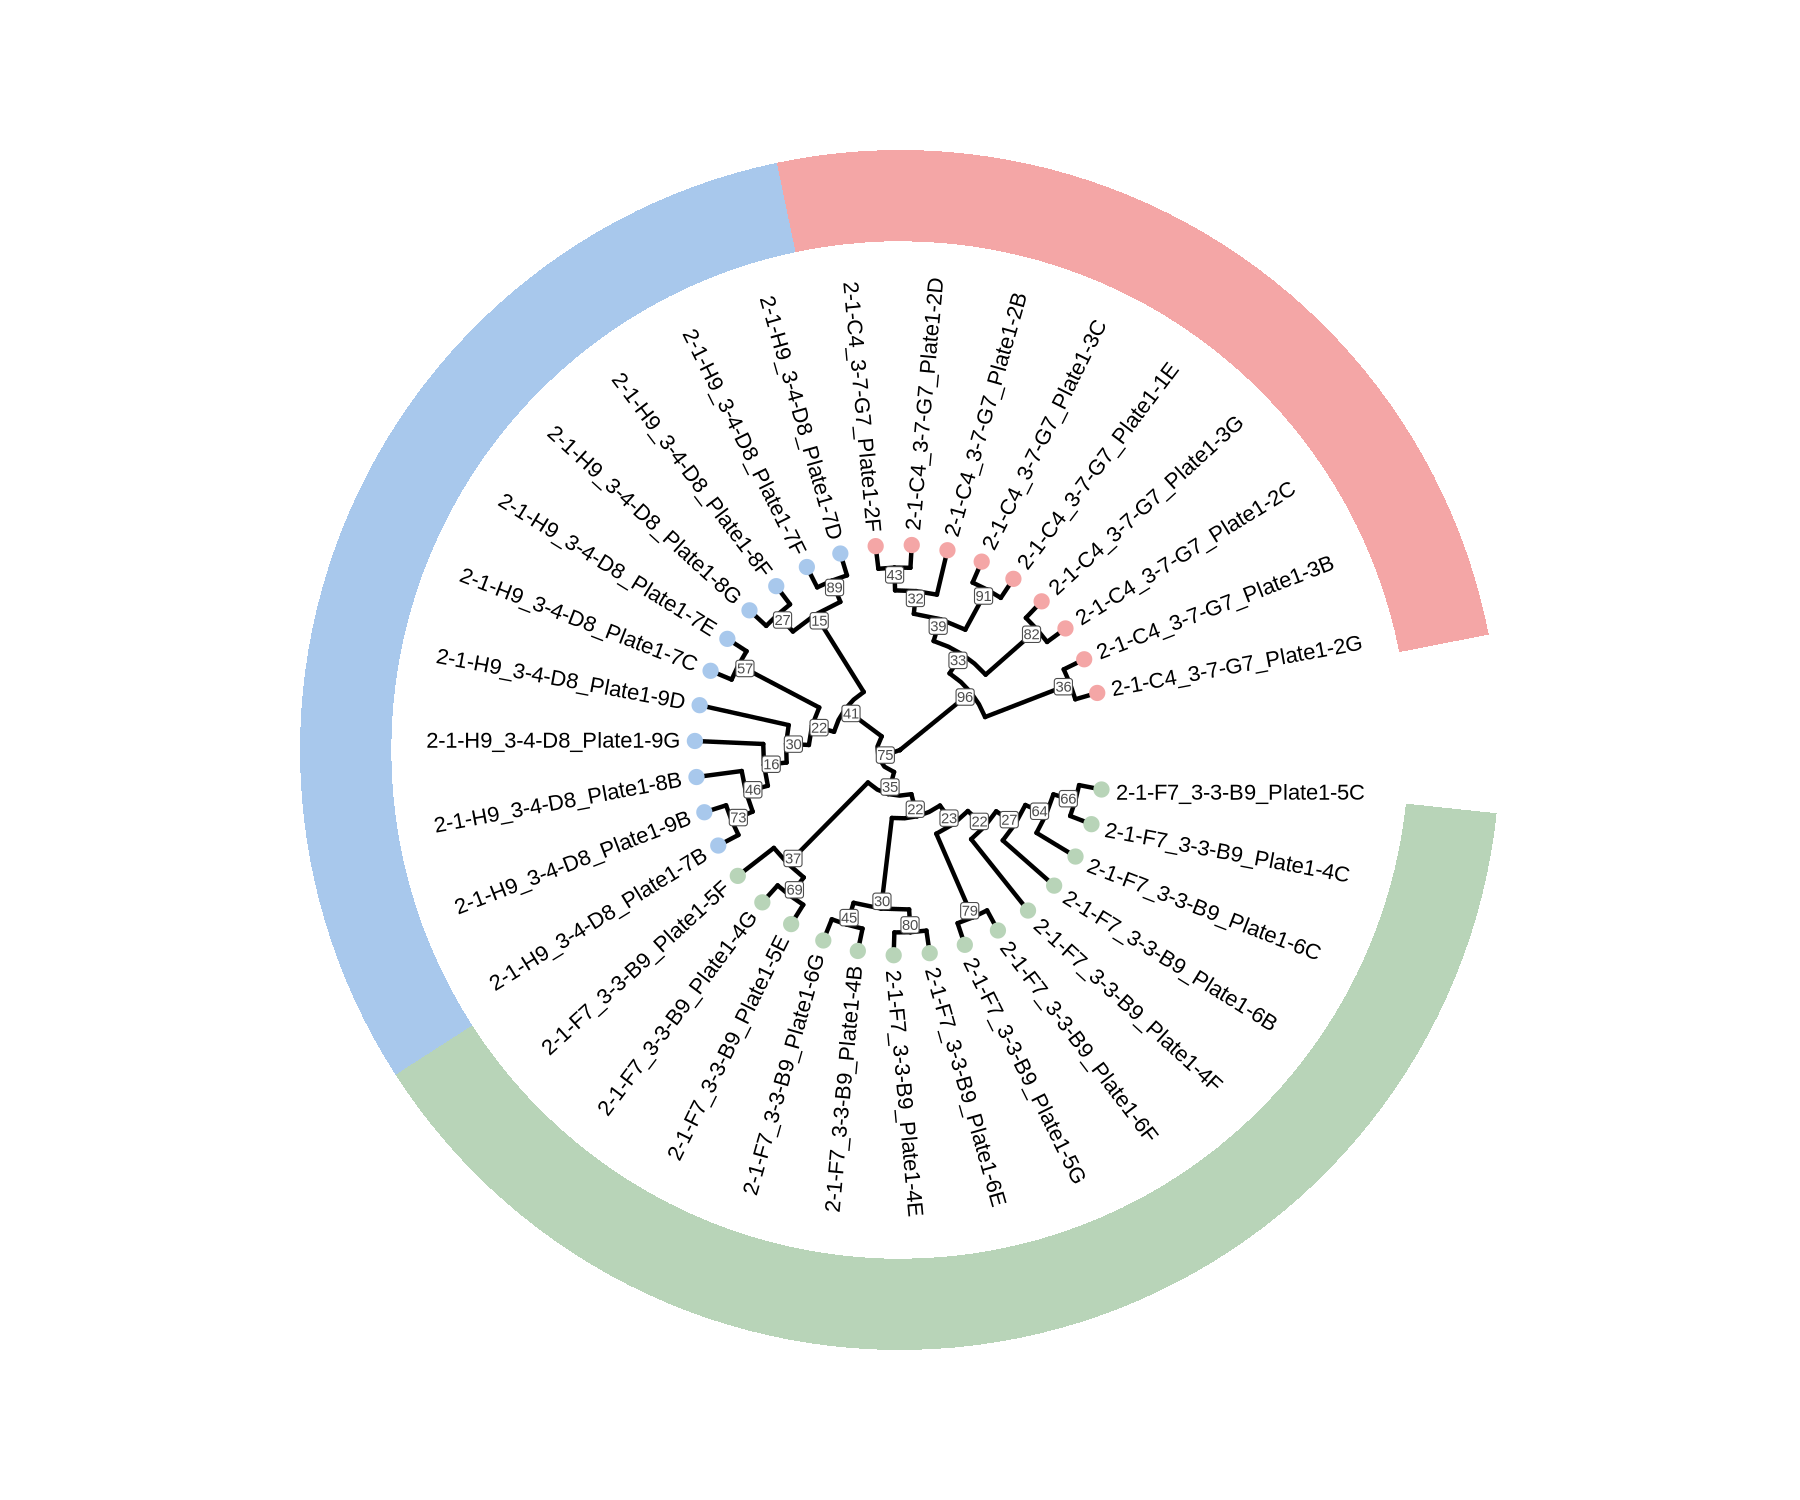

In [ ]:
# Draw bootstrap labels last so they sit on top of branches (small white boxes, low-key)
if (SHOW_BOOTSTRAP && "bootstrap_lab" %in% names(p$data)) {
  p <- p + geom_label2(
    aes(subset = !isTip & !is.na(bootstrap_lab),
        label = bootstrap_lab,
        x = x - BOOTSTRAP_NUDGE),
    size          = BOOTSTRAP_LABEL_SIZE,
    color         = BOOTSTRAP_COLOR,
    fill          = "white",
    label.padding = unit(0.06, "lines"),
    na.rm         = TRUE
  )
  cat("Added bootstrap support values at internal nodes\n")
}

# No on-plot legend for TW1nt12k (clone legend lives on the CA panel)
p <- p + theme(
  plot.margin = margin(0, 0, 0, 0),
  legend.position = "none"
)

cat("Applied final theming\n")

# Display the plot
print(p)


In [ ]:
# Save outputs
ggsave(paste0(OUTPUT_PREFIX, '.viewPhylo.pdf'), p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)
ggsave(paste0(OUTPUT_PREFIX, '.viewPhylo.png'), p, width = PLOT_WIDTH, height = PLOT_HEIGHT, dpi = DPI)

cat("Tree visualization saved to:\n")
cat(paste0("  ", OUTPUT_PREFIX, ".viewPhylo.pdf\n"))
cat(paste0("  ", OUTPUT_PREFIX, ".viewPhylo.png\n"))


Tree visualization saved to:
  20210920_HCT116_TW1nt12k_circular_ggtree_bootstrap.viewPhylo.pdf
  20210920_HCT116_TW1nt12k_circular_ggtree_bootstrap.viewPhylo.png


## CA2nt24k Dataset Visualization

Now let's create the same visualization using the CA2nt24k dataset:


In [ ]:
# Configuration for CA2nt24k dataset (same DATA_DIR as the TW1nt12k section)
CA_SAMPLESHEET_FILE <- file.path(DATA_DIR, "20210920_HCT116_2-6nt24k_samplesheet.csv")
CA_TREE_FILE <- file.path(
  DATA_DIR,
  "results_CA2nt24k_500targets_minqual0_minreads10/phylo/20210920_HCT116_CA2nt24k_rerun.buildPhylo.newick-bootstrap.txt"
)
CA_OUTPUT_PREFIX <- file.path(DATA_DIR, "20210920_HCT116_CA2nt24k_circular_ggtree_bootstrap")

cat("CA2nt24k Configuration:\n")
cat("Samplesheet:", CA_SAMPLESHEET_FILE, "\n")
cat("Tree file:", CA_TREE_FILE, "\n")
cat("Output prefix:", CA_OUTPUT_PREFIX, "\n")


CA2nt24k Configuration:
Samplesheet: 20210920_HCT116_2-6nt24k_samplesheet.csv 
Tree file: results_CA2nt24k_500targets_minqual0_minreads10/phylo/20210920_HCT116_CA2nt24k_rerun.buildPhylo.newick-bootstrap.txt 
Output prefix: 20210920_HCT116_CA2nt24k_circular_ggtree_bootstrap 


In [ ]:
# Load CA2nt24k tree and sample data
ca_tree <- read.tree(CA_TREE_FILE)
ca_samples <- read.csv(CA_SAMPLESHEET_FILE, stringsAsFactors = FALSE)

# Handle missing values with defaults
ca_samples$color <- ifelse(is.na(ca_samples$color) | ca_samples$color == '', 'grey', ca_samples$color)

cat("CA2nt24k data loaded:\n")
cat("Tree tips:", length(ca_tree$tip.label), "\n")
cat("Samples:", nrow(ca_samples), "\n")
cat("Unique groups:", length(unique(ca_samples$group)), "\n")
print(unique(ca_samples$group))


CA2nt24k data loaded:
Tree tips: 49 
Samples: 54 
Unique groups: 3 
[1] "2-1-C4_3-7-G7" "2-1-F7_3-3-B9" "2-1-H9_3-4-D8"


In [ ]:
# Prepare CA2nt24k data for visualization
ca_tip_label_data <- ca_samples %>% 
  select(sample_id, color) %>%
  rename(label = sample_id)
rownames(ca_tip_label_data) <- ca_tip_label_data$label

ca_group_ring_data <- ca_samples %>%
  select(sample_id, color, group) %>%
  rename(label = sample_id)

# Apply label cleaning
ca_group_ring_data$group <- rename_labels(ca_group_ring_data$group, rename_dict)
ca_group_names_clean <- rename_labels(unique(ca_samples$group), rename_dict)
ca_group_colors_map <- setNames(unique(ca_samples$color), ca_group_names_clean)

cat("CA2nt24k data preparation completed!\n")
cat("Group colors map:\n")
print(ca_group_colors_map)


CA2nt24k data preparation completed!
Group colors map:
2-1-C4_3-7-G7 2-1-F7_3-3-B9 2-1-H9_3-4-D8 
    "#f4a6a6"     "#b8d4b8"     "#a8c8ec" 


In [ ]:
# Create CA2nt24k circular tree visualization
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 150)

# Basic tree plot
ca_p <- ggtree(ca_tree, layout = 'circular', branch.length = 'none', size = 1)

# Join color data to tree for tip labels
ca_p <- ca_p %<+% ca_tip_label_data

# Add tip labels (using same style as TW1nt12k)
if (COLOR_BACKGROUND) {
  ca_p <- ca_p + geom_tiplab(aes(fill = color), 
                             size = TIP_LABEL_SIZE, color = 'black', 
                             geom = 'label', 
                             label.padding = unit(0.1, "lines")) +
    scale_fill_identity()
} else {
  ca_p <- ca_p + geom_tippoint(aes(color = color), size = NODE_SIZE) +
    geom_tiplab(size = TIP_LABEL_SIZE, offset = 0.5) +
    scale_color_identity()
}

cat("CA2nt24k basic tree structure created!\n")


CA2nt24k basic tree structure created!


In [ ]:
# Bootstrap values as integer percentages (same style as TW1nt12k). Drawn after the clone ring.
if (SHOW_BOOTSTRAP) {
  ca_node_labels <- ca_tree$node.label
  n_nonempty_ca  <- sum(!is.na(ca_node_labels) & nzchar(ca_node_labels))
  cat(sprintf("CA2nt24k bootstrap check: %d internal nodes, %d with non-empty labels\n",
              length(ca_node_labels), n_nonempty_ca))
  if (n_nonempty_ca > 0) {
    n_tips_ca         <- length(ca_tree$tip.label)
    internal_nodes_ca <- seq(n_tips_ca + 1L, n_tips_ca + ca_tree$Nnode)
    boot_numeric_ca   <- suppressWarnings(as.numeric(ca_tree$node.label))
    boot_pct_ca       <- ifelse(!is.na(boot_numeric_ca) & boot_numeric_ca <= 1.5,
                                boot_numeric_ca * 100, boot_numeric_ca)
    bootstrap_lab_ca  <- ifelse(is.na(boot_pct_ca), NA_character_,
                                as.character(round(boot_pct_ca)))
    bootstrap_df_ca   <- data.frame(
      node          = internal_nodes_ca,
      bootstrap     = boot_pct_ca,
      bootstrap_lab = bootstrap_lab_ca,
      stringsAsFactors = FALSE
    )
    ca_p <- ca_p %<+% bootstrap_df_ca
    cat("Joined CA2nt24k bootstrap values (labels drawn after the clone ring)\n")
  } else {
    warning(
      "CA2nt24k: No non-empty internal node labels found. ",
      "Pass a bootstrap newick (e.g. *.buildPhylo.newick-bootstrap.txt) or set SHOW_BOOTSTRAP <- FALSE."
    )
  }
} else {
  cat("Bootstrap display disabled (SHOW_BOOTSTRAP = FALSE)\n")
}

CA2nt24k bootstrap check: 48 internal nodes, 47 with non-empty labels
Joined CA2nt24k bootstrap values (labels drawn after the clone ring)


! The following column names/name: color are/is the same to tree data, the tree data column names are : label, y, angle, color, bootstrap, bootstrap_lab.

Warning message in geom_label2(aes(subset = !isTip & !is.na(bootstrap_lab), label = bootstrap_lab, :
“Ignoring unknown parameters: `label.size`”


Added CA2nt24k bootstrap support values at internal nodes
CA2nt24k visualization completed!


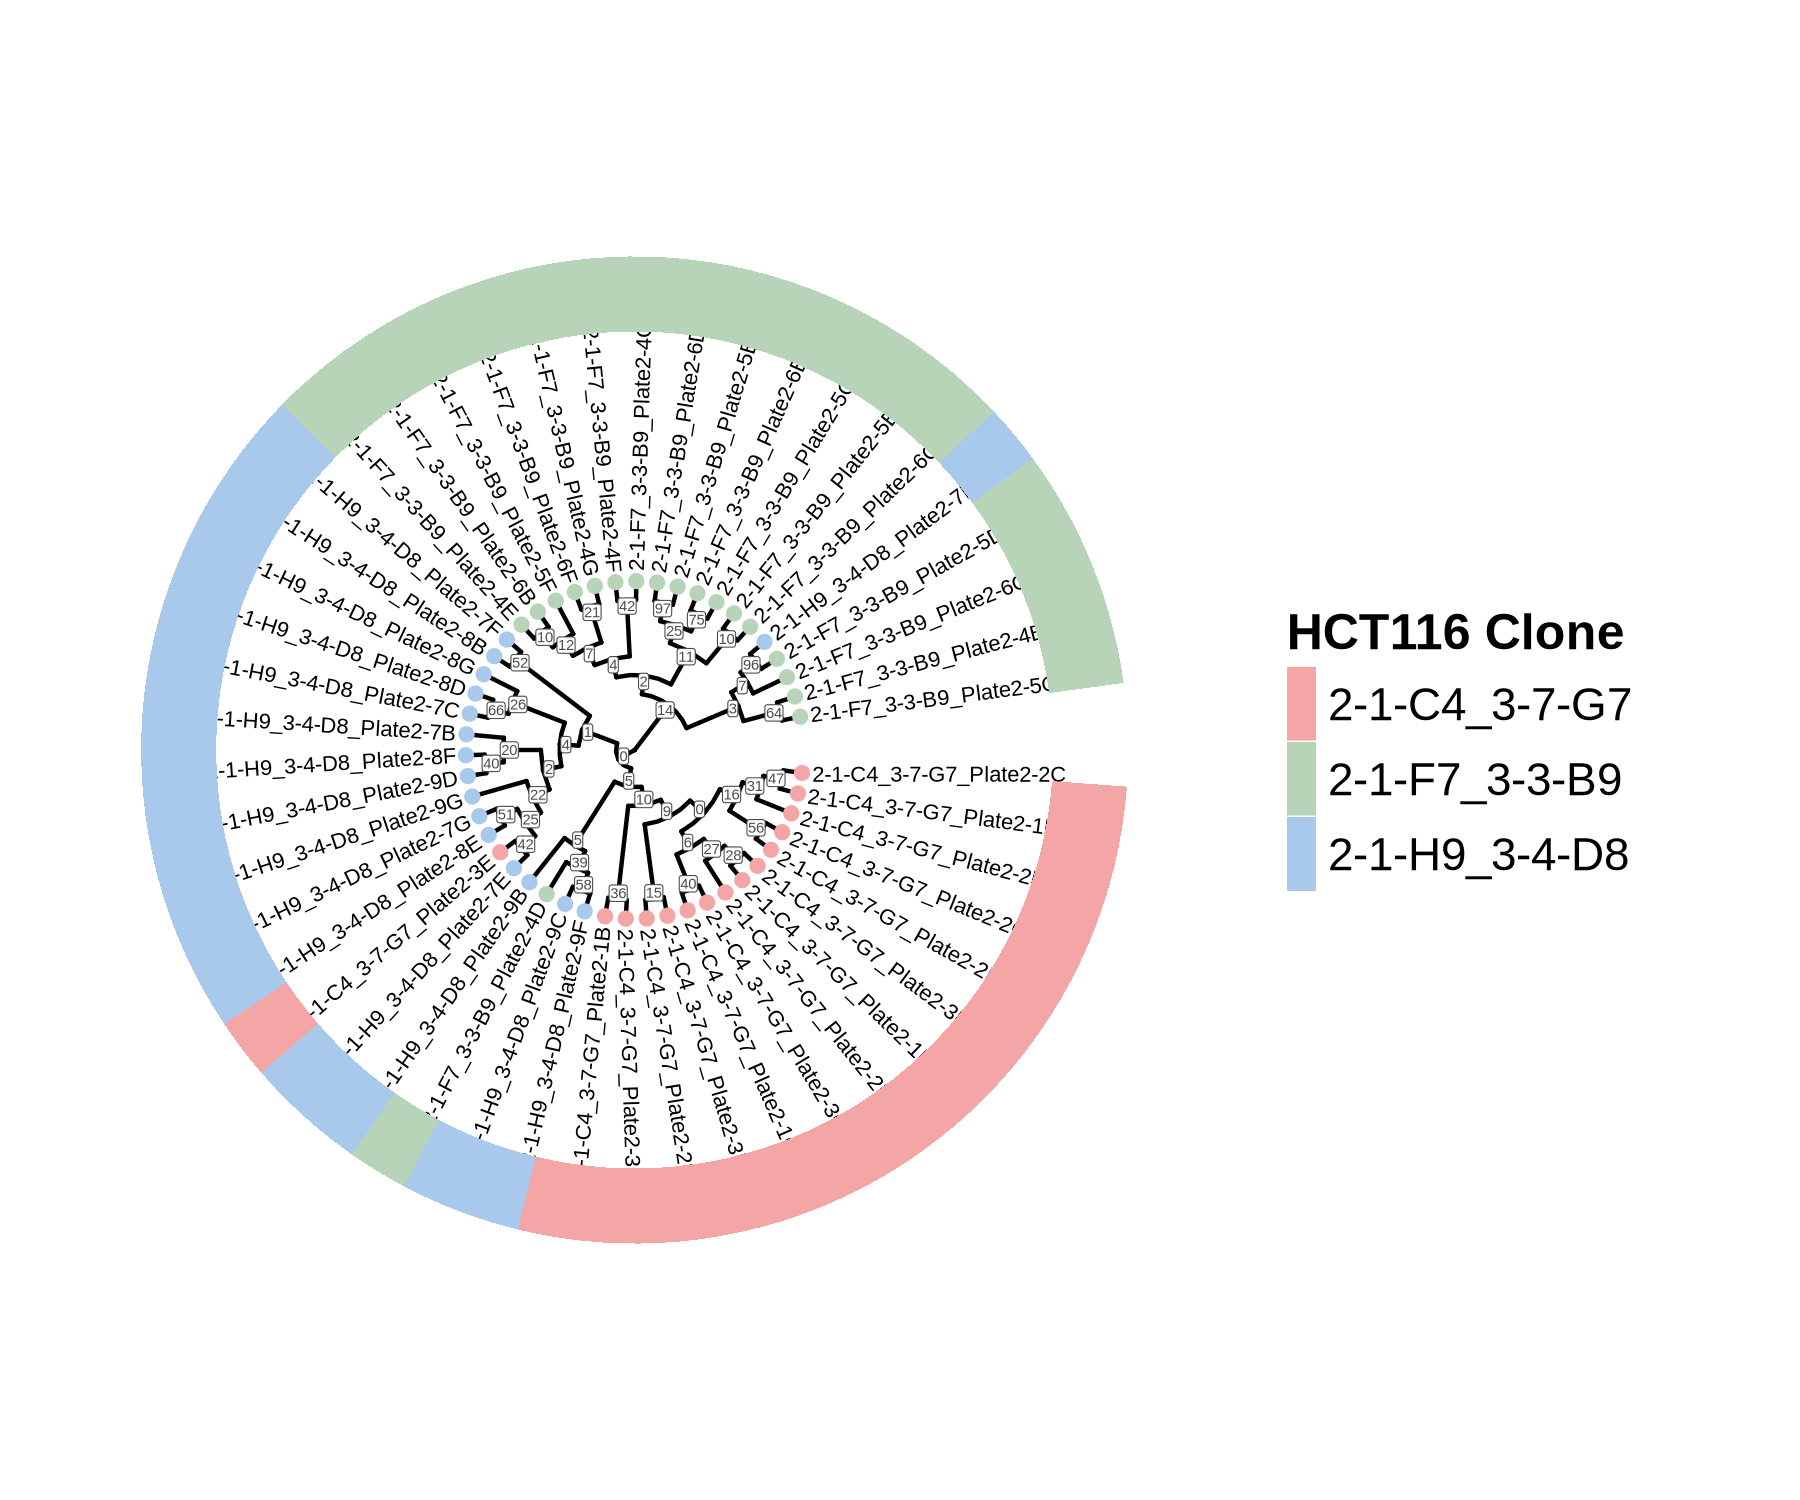

In [ ]:
# Add inner ring and styling for CA2nt24k (this panel carries the shared clone legend)
ca_p <- ca_p + geom_fruit(
    data = ca_group_ring_data,
    geom = geom_tile,
    mapping = aes(y = label, x = 2, fill = group),
    pwidth = 0.1,
    width = RING_WIDTH,
    offset = INNER_RING_OFFSET
  ) + 
  scale_fill_manual(
    values = ca_group_colors_map,
    name = "HCT116 Clone",
    guide = guide_legend(
      order = 1,
      keyheight = unit(2.5, "lines"),
      keywidth = unit(1, "lines"),
      label.position = "right",
      byrow = TRUE
    )
  )

if (SHOW_BOOTSTRAP && "bootstrap_lab" %in% names(ca_p$data)) {
  ca_p <- ca_p + geom_label2(
    aes(subset = !isTip & !is.na(bootstrap_lab),
        label = bootstrap_lab,
        x = x - BOOTSTRAP_NUDGE),
    size          = BOOTSTRAP_LABEL_SIZE,
    color         = BOOTSTRAP_COLOR,
    fill          = "white",
    label.padding = unit(0.06, "lines"),
    na.rm         = TRUE
  )
  cat("Added CA2nt24k bootstrap support values at internal nodes\n")
}

ca_p <- ca_p + theme(
  plot.margin = margin(0.3, 1.8, 0.3, 0.3, unit = "cm"),
  legend.text = element_text(size = LEGEND_TEXT_SIZE),
  legend.title = element_text(size = LEGEND_TITLE_SIZE, face = "bold"),
  legend.background = element_rect(fill = "white", colour = NA),
  legend.box = "vertical",
  legend.position = "right",
  legend.justification = c(0.5, 0.5),
  legend.box.spacing = unit(0.4, "cm")
)

cat("CA2nt24k visualization completed!\n")

# Display the plot
print(ca_p)


In [ ]:
# Save CA2nt24k outputs (slightly wider canvas so the clone legend sits to the right of the tree)
ggsave(paste0(CA_OUTPUT_PREFIX, '.viewPhylo.pdf'), ca_p, width = PLOT_WIDTH + 2, height = PLOT_HEIGHT, dpi = DPI)
ggsave(paste0(CA_OUTPUT_PREFIX, '.viewPhylo.png'), ca_p, width = PLOT_WIDTH + 2, height = PLOT_HEIGHT, dpi = DPI)

cat("CA2nt24k tree visualization saved to:\n")
cat(paste0("  ", CA_OUTPUT_PREFIX, ".viewPhylo.pdf\n"))
cat(paste0("  ", CA_OUTPUT_PREFIX, ".viewPhylo.png\n"))


CA2nt24k tree visualization saved to:
  20210920_HCT116_CA2nt24k_circular_ggtree_bootstrap.viewPhylo.pdf
  20210920_HCT116_CA2nt24k_circular_ggtree_bootstrap.viewPhylo.png


## Summary

This notebook now creates visualizations for both datasets:

1. **TW1nt12k** (Sections 1-9): Creates `20210920_HCT116_TW1nt12k_circular_ggtree.viewPhylo.pdf/png`
2. **CA2nt24k** (Section 10): Creates `20210920_HCT116_CA2nt24k_circular_ggtree.viewPhylo.pdf/png`

### Legend Options:
- **Show legend**: Use `guide = guide_legend(...)` (current setting)
- **Hide legend**: Replace with `guide = "none"`

### Quick Tips:
- Both visualizations use the same styling parameters from Section 2
- The CA2nt24k section reuses all the same functions and styling
- You can modify legend spacing, colors, and titles in both sections independently
